In [99]:
import sys; sys.path.append("../../"); sys.path.append("../../../.."); sys.path.append("../../../gmsh/"); sys.path.append("../../experiments/"); sys.path.append("../../../")
import experiment_helper
import igl
from periodic_simulation_setup import *
import json

import sys; sys.path.append("../../"); sys.path.append("../../../.."); sys.path.append("../../../gmsh/"); sys.path.append("../../experiments/"); sys.path.append("../../../")
import experiment_helper
import igl
from periodic_simulation_setup import *
import json



In [100]:
stiffness_data_collection = []

In [101]:
hessianShiftForStiffness = 1e-7


### Pattern 1: Parallel tubes

In [102]:
angle = 90
r = 2.5
avg_len = 0.08


h = 5
dash_point = np.array([np.cos(angle / 180 * np.pi), np.sin(angle / 180 * np.pi)]) * r + np.array([0, 0])
m, marker = pattern_generator_using_gmsh.get_single_dash(h, avg_len, avg_len, dash_point = dash_point)

finalMarkers = np.where(np.array(marker) == 1)[0]
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, flip_orientation= 0)
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, axis = 1, flip_orientation= 1)

# vertices = m.vertices()
# vertices *= 4
# m = MeshFEM.mesh.Mesh(vertices, m.elements())
fusedVtx = get_fusedVtx_using_markers(len(m.vertices()), finalMarkers)

ipu = inflation.InflatablePeriodicUnit(m, fusedVtx = fusedVtx, epsilon = 1e-9)

In [103]:
viewer = TriMeshViewer(ipu, width=768, height=640)
viewer.showWireframe(False)
viewer.show()


Renderer(camera=PerspectiveCamera(aspect=1.2, children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), …

In [104]:
import experiment_helper

In [105]:
# pressure = 0.8
stiffness_pressure = 0.4
scale_factor_pressure = 0.01

In [106]:
allowBending = False
useTFT = True
disableFusedRegionTFT = False

In [107]:
def cb(i):
    viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])

In [108]:
ipu.setVars(np.load('parallel_tubes.npy'))

In [109]:
# Choose strategy for constraining rigid motion
fixedVars, hessianShift = periodic_unit_helper.get_center_fixedVars(ipu), 0
if not allowBending:
    fixedVars, hessianShift = [ipu.numVars() - 2, ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6

ipu.sheet.setUseTensionFieldEnergy(useTFT)
ipu.sheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    ipu.sheet.disableFusedRegionTensionFieldTheory(False)
ipu.sheet.pressure = stiffness_pressure

benchmark.reset()
print(allowBending, stiffness_pressure, hessianShift, fixedVars)

opts.niter = 500
opts.gradTol = 1e-10
print(opts.factorizer)

cr = inflation.inflation_newton(ipu, fixedVars, options = opts, callback=cb, hessianShift = hessianShift)
viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
benchmark.report()

False 0.4 1e-06 [121311, 121312]
CholeskyProvider.CatamariNesdis
InflatablePeriodicUnit.hessianSparsityPattern	0.248638	1
    Compress Matrix	0.0862958	2
    InflatablePeriodicUnit.computeAHA	0.0863161	1
    InflatablePeriodicUnit.hessianPeriodicPressurePotential	0.00490594	1
            baseHessianSparsityPattern	2.14577e-06	1
InflatableSheet setVars	0.000717878	1
Newton iterations	0.343127	1
    InflatableSheet energy	0.00173426	3
    Newton iterate	0.34074	1
        Preamble	0.340739	1
            Callback	0.324147	1
                InflatableSheet energy	0.00045085	1
            InflatablePeriodicUnit.getSheetGradient	0.00218201	1
                InflatableSheet gradient	0.00175691	2
            InflatablePeriodicUnit.sensitivitycache.update	0.00956488	1
            InflatableSheet energy	0.00168896	3
Full time	0.91518


In [110]:
# np.save('parallel_tubes.npy', ipu.getVars())

In [111]:
bending_stiffness, alphas, stiffness_coefficients = experiment_helper.helper_compute_bending_stiffness(ipu, cb, result_folder='stiffness', name = 'parallel_tube', variable = 0, render_images = True)

In [112]:
betas = np.linspace(0, np.pi, 1000)
optimizer = inflation.get_inflation_optimizer(ipu, ipu.getStretchingStiffnessFixedVars(), opts, callback=cb, hessianShift = hessianShiftForStiffness)
stretchingStiffness = inflation.getStretchingStiffness(ipu, betas, optimizer, hessianShiftForStiffness, ipu.getStretchingStiffnessFixedVars())


In [113]:
stiffness_data_collection.append([bending_stiffness, stretchingStiffness, alphas, stiffness_coefficients])

### Pattern 2: Dashline

In [114]:
a = 2
avg_len = 0.08
radius = 0.8

In [115]:
angle = 45
r = 0.9

In [116]:

h = 5
dash_point = np.array([np.cos(angle / 180 * np.pi), np.sin(angle / 180 * np.pi)]) * r + np.array([0, 0])
m, marker = pattern_generator_using_gmsh.get_single_dash(h, avg_len, avg_len, dash_point = dash_point)

finalMarkers = np.where(np.array(marker) == 1)[0]
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, flip_orientation= 0)
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, axis = 1, flip_orientation= 1)

# vertices = m.vertices()
# vertices *= 4
# m = MeshFEM.mesh.Mesh(vertices, m.elements())
fusedVtx = get_fusedVtx_using_markers(len(m.vertices()), finalMarkers)

In [117]:
ipu = inflation.InflatablePeriodicUnit(m, fusedVtx = fusedVtx, epsilon = 1e-9)

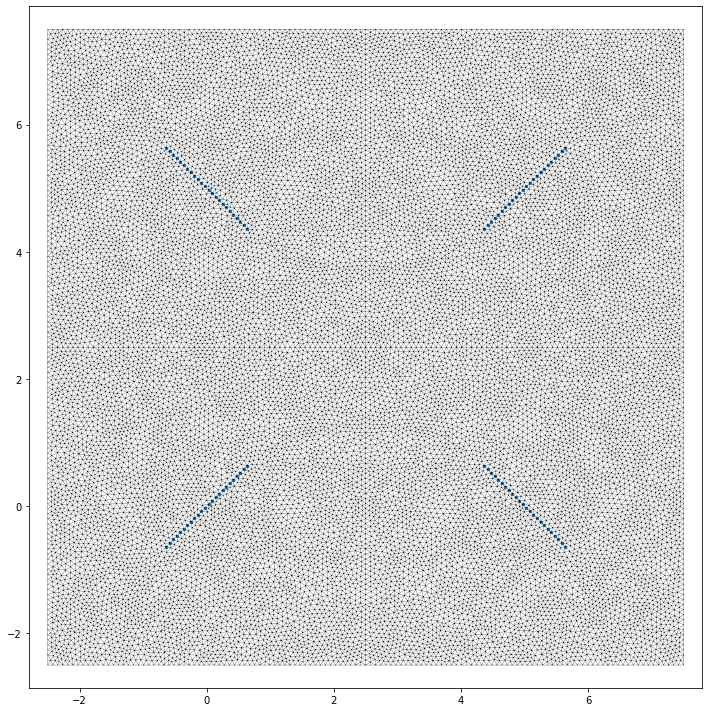

In [118]:
visualization.plot_2d_mesh(m, pointList = fusedVtx, width = 10, height = 10)

In [119]:
viewer = TriMeshViewer(ipu, width=768, height=640)
viewer.showWireframe(False)
viewer.show()

Renderer(camera=PerspectiveCamera(aspect=1.2, children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), …

In [120]:
# pressure = 0.8
stiffness_pressure = 0.4
scale_factor_pressure = 0.01

In [121]:
allowBending = False
useTFT = True
disableFusedRegionTFT = False

In [122]:
def cb(i):
    viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])

In [123]:
ipu.setVars(np.load('dash_line.npy'))

In [124]:
# Choose strategy for constraining rigid motion
fixedVars, hessianShift = periodic_unit_helper.get_center_fixedVars(ipu), 0
if not allowBending:
    fixedVars, hessianShift = [ipu.numVars() - 2, ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6

ipu.sheet.setUseTensionFieldEnergy(useTFT)
ipu.sheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    ipu.sheet.disableFusedRegionTensionFieldTheory(False)
ipu.sheet.pressure = stiffness_pressure

benchmark.reset()
print(allowBending, stiffness_pressure, hessianShift, fixedVars)

opts.niter = 500
opts.gradTol = 1e-10
print(opts.factorizer)

cr = inflation.inflation_newton(ipu, fixedVars, options = opts, callback=cb, hessianShift = hessianShift)
viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
benchmark.report()

False 0.4 1e-06 [120051, 120052]
CholeskyProvider.CatamariNesdis
InflatablePeriodicUnit.hessianSparsityPattern	0.233702	1
    Compress Matrix	0.0813894	2
    InflatablePeriodicUnit.computeAHA	0.0774419	1
    InflatablePeriodicUnit.hessianPeriodicPressurePotential	0.00414586	1
            baseHessianSparsityPattern	1.19209e-06	1
InflatableSheet setVars	0.000696898	1
Newton iterations	0.3686	1
    InflatableSheet energy	0.00174212	3
    Newton iterate	0.36672	1
        Preamble	0.36672	1
            Callback	0.350507	1
                InflatableSheet energy	0.000452995	1
            InflatablePeriodicUnit.getSheetGradient	0.00214005	1
                InflatableSheet gradient	0.00193715	2
            InflatablePeriodicUnit.sensitivitycache.update	0.00876498	1
            InflatableSheet energy	0.00184798	3
Full time	0.927062


In [125]:
cr.success

True

In [126]:
# np.save('dash_line.npy', ipu.getVars())

In [127]:
bending_stiffness, alphas, stiffness_coefficients = experiment_helper.helper_compute_bending_stiffness(ipu, cb, result_folder='stiffness', name = 'dash_line', variable = 0, render_images = True)

In [128]:
betas = np.linspace(0, np.pi, 1000)
optimizer = inflation.get_inflation_optimizer(ipu, ipu.getStretchingStiffnessFixedVars(), opts, callback=cb, hessianShift = hessianShiftForStiffness)
stretchingStiffness = inflation.getStretchingStiffness(ipu, betas, optimizer, hessianShiftForStiffness, ipu.getStretchingStiffnessFixedVars())


In [129]:
stiffness_data_collection.append([bending_stiffness, stretchingStiffness, alphas, stiffness_coefficients])

### Pattern 3: Cosine curve

In [130]:
use_half_period = False
h = 5
m, marker = pattern_generator_using_gmsh.get_cosine_curve(h, avg_len, avg_len, amplitude=0.1653061224489796, end_threshold = 0.0, use_half_period=use_half_period)

finalMarkers = np.where(np.array(marker) == 1)[0]
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, flip_orientation= 0)
m, finalMarkers = periodic_unit_helper.shift_and_merge_2D_periodic_mesh(m, finalMarkers, axis = 1, flip_orientation= 1)

# vertices = m.vertices()
# vertices *= 4
# m = MeshFEM.mesh.Mesh(vertices, m.elements())
fusedVtx = get_fusedVtx_using_markers(len(m.vertices()), finalMarkers)


num_seg: 62
121


In [131]:
ipu = inflation.InflatablePeriodicUnit(m, fusedVtx = fusedVtx, epsilon = 1e-9)

In [132]:
viewer = TriMeshViewer(ipu, width=768, height=640)
viewer.showWireframe(False)
viewer.show()

Renderer(camera=PerspectiveCamera(aspect=1.2, children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), …

In [133]:
# pressure = 0.8
stiffness_pressure = 0.4
scale_factor_pressure = 0.01

In [134]:
allowBending = False
useTFT = True
disableFusedRegionTFT = False

In [135]:
def cb(i):
    viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])

In [136]:
ipu.setVars(np.load("cosine_curve.npy"))

In [137]:
# Choose strategy for constraining rigid motion
fixedVars, hessianShift = periodic_unit_helper.get_center_fixedVars(ipu), 0
if not allowBending:
    fixedVars, hessianShift = [ipu.numVars() - 2, ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6

ipu.sheet.setUseTensionFieldEnergy(useTFT)
ipu.sheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    ipu.sheet.disableFusedRegionTensionFieldTheory(False)
ipu.sheet.pressure = stiffness_pressure

benchmark.reset()
print(allowBending, stiffness_pressure, hessianShift, fixedVars)

opts.niter = 200
opts.gradTol = 1e-7
print(opts.factorizer)

cr = inflation.inflation_newton(ipu, fixedVars, options = opts, callback=cb, hessianShift = hessianShift)
viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
benchmark.report()

False 0.4 1e-06 [193539, 193540]
CholeskyProvider.CatamariNesdis
InflatablePeriodicUnit.hessianSparsityPattern	0.31566	1
    Compress Matrix	0.129182	2
    InflatablePeriodicUnit.computeAHA	0.0965478	1
    InflatablePeriodicUnit.hessianPeriodicPressurePotential	0.00716615	1
            baseHessianSparsityPattern	9.53674e-07	1
InflatableSheet setVars	0.00121498	1
Newton iterations	0.526514	1
    InflatableSheet energy	0.00317001	3
    Newton iterate	0.523157	1
        Preamble	0.523156	1
            Callback	0.495606	1
                InflatableSheet energy	0.000710964	1
            InflatablePeriodicUnit.getSheetGradient	0.00424409	1
                InflatableSheet gradient	0.00293803	2
            InflatablePeriodicUnit.sensitivitycache.update	0.0142481	1
            InflatableSheet energy	0.00304222	3
Full time	1.33422


In [138]:
cr.success

True

In [139]:
# np.save("cosine_curve.npy", ipu.getVars())

In [140]:
bending_stiffness, alphas, stiffness_coefficients = experiment_helper.helper_compute_bending_stiffness(ipu, cb, result_folder='stiffness', name = 'cosine', variable = 0, render_images = True)

In [141]:
betas = np.linspace(0, np.pi, 1000)
optimizer = inflation.get_inflation_optimizer(ipu, ipu.getStretchingStiffnessFixedVars(), opts, callback=cb, hessianShift = hessianShiftForStiffness)
stretchingStiffness = inflation.getStretchingStiffness(ipu, betas, optimizer, hessianShiftForStiffness, ipu.getStretchingStiffnessFixedVars())


In [142]:
stiffness_data_collection.append([bending_stiffness, stretchingStiffness, alphas, stiffness_coefficients])

### Pattern 4: Elliptic holes

In [143]:
time = '2024_01_17_11_33'
name = 'square_with_ellipse_hole_angle_width_height'
experiment_file = '../../experiments/parallelized_experiments/output/{}/{}/experiment_result.json'.format(name, time)
stiffness_path = '../../experiments/parallelized_experiments/output/{}/{}'.format(name, time)

Renderer(camera=PerspectiveCamera(children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), quaternion=(…

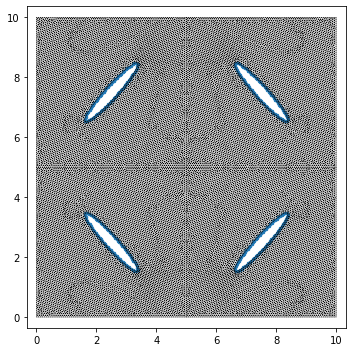

In [144]:
label = '42.00_0.20_1.30'

m = MeshFEM.mesh.Mesh('../../experiments/parallelized_experiments/output/{}/{}/{}/mesh_{}_{}.obj'.format(name, time, label, name, label))
fusing_vtx = np.load('../../experiments/parallelized_experiments/output/{}/{}/{}/fusedVtx_{}_{}.npy'.format(name, time, label, name, label))

visualization.plot_2d_mesh(m, pointList=fusing_vtx, width=5, height=5)
vertices = m.vertices()
vertices = np.concatenate((vertices, np.zeros((len(vertices), 1))), axis = 1)
m = MeshFEM.mesh.Mesh(vertices, m.elements())
# fusedVtx = get_fusedVtx_using_markers(len(m.vertices()), finalMarkers)

ipu = inflation.InflatablePeriodicUnit(m, fusedVtx = fusing_vtx, epsilon = 1e-9)
ipu.setVars(np.load('../../experiments/parallelized_experiments/output/{}/{}/{}/{}_dofs_before_stiffness_{}.npy'.format(name, time, label, name, label)))
viewer = TriMeshViewer(ipu, width=500, height=500)
viewer.showWireframe(False)
viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
viewer.show()

In [145]:
# pressure = 0.8
stiffness_pressure = 0.4
scale_factor_pressure = 0.01

In [146]:
allowBending = False
useTFT = True
disableFusedRegionTFT = False

In [147]:
def cb(i):
    viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])

In [148]:
viewer.show()

Renderer(camera=PerspectiveCamera(children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), quaternion=(…

In [149]:
# Choose strategy for constraining rigid motion
fixedVars, hessianShift = periodic_unit_helper.get_center_fixedVars(ipu), 0
if not allowBending:
    fixedVars, hessianShift = [ipu.numVars() - 2, ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6

ipu.sheet.setUseTensionFieldEnergy(useTFT)
ipu.sheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    ipu.sheet.disableFusedRegionTensionFieldTheory(False)
ipu.sheet.pressure = stiffness_pressure

benchmark.reset()
print(allowBending, stiffness_pressure, hessianShift, fixedVars)

opts.niter = 500
opts.gradTol = 1e-10
print(opts.factorizer)

cr = inflation.inflation_newton(ipu, fixedVars, options = opts, callback=cb, hessianShift = hessianShift)
viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
benchmark.report()

False 0.4 1e-06 [144087, 144088]
CholeskyProvider.CatamariNesdis
InflatablePeriodicUnit.hessianSparsityPattern	0.253309	1
    Compress Matrix	0.0944259	2
    InflatablePeriodicUnit.computeAHA	0.0866401	1
    InflatablePeriodicUnit.hessianPeriodicPressurePotential	0.00827789	1
            baseHessianSparsityPattern	9.53674e-07	1
InflatableSheet setVars	0.000801086	1
Newton iterations	0.442577	1
    InflatableSheet energy	0.0018208	3
    Newton iterate	0.440606	1
        Preamble	0.440605	1
            Callback	0.420363	1
                InflatableSheet energy	0.000538111	1
            InflatablePeriodicUnit.getSheetGradient	0.00276899	1
                InflatableSheet gradient	0.00223184	2
            InflatablePeriodicUnit.sensitivitycache.update	0.0122218	1
            InflatableSheet energy	0.00176001	3
Full time	1.03219


In [150]:
bending_stiffness, alphas, stiffness_coefficients = experiment_helper.helper_compute_bending_stiffness(ipu, cb, result_folder='stiffness', name = 'parallel_tube', variable = 0, render_images = True)

In [151]:
betas = np.linspace(0, np.pi, 1000)
optimizer = inflation.get_inflation_optimizer(ipu, ipu.getStretchingStiffnessFixedVars(), opts, callback=cb, hessianShift = hessianShiftForStiffness)
stretchingStiffness = inflation.getStretchingStiffness(ipu, betas, optimizer, hessianShiftForStiffness, ipu.getStretchingStiffnessFixedVars())


In [152]:
stiffness_data_collection.append([bending_stiffness, stretchingStiffness, alphas, stiffness_coefficients])

### Pattern 5: isotrpic three star

In [156]:
a = 2
avg_len = 0.08
radius = 0.8
ipu, m, marker = pattern_generator_using_gmsh.get_three_star_hex(a, radius, num_spikes=3, avg_len_boundary = avg_len, avg_len_embeddings = avg_len)        
finalMarkers = np.where(np.array(marker) == 1)[0]

fusedVtx = get_fusedVtx_using_markers(len(m.vertices()), finalMarkers)

ipu = inflation.InflatablePeriodicUnit(m, fusedVtx = fusedVtx, epsilon = 1e-9)

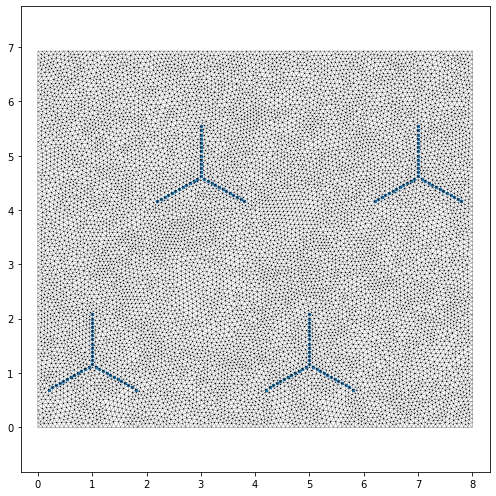

In [157]:
visualization.plot_2d_mesh(m, pointList=fusedVtx)

In [158]:
viewer = TriMeshViewer(ipu, width=768, height=640)
viewer.showWireframe(False)
viewer.show()

Renderer(camera=PerspectiveCamera(aspect=1.2, children=(PointLight(color='#999999', position=(0.0, 0.0, 5.0), …

In [159]:
# pressure = 0.8
stiffness_pressure = 0.4
scale_factor_pressure = 0.01

In [160]:
allowBending = False
useTFT = True
disableFusedRegionTFT = False

In [161]:
def cb(i):
    viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])

In [162]:
ipu.setVars(np.load("three_star.npy"))

In [163]:
# Choose strategy for constraining rigid motion
fixedVars, hessianShift = periodic_unit_helper.get_center_fixedVars(ipu), 0
if not allowBending:
    fixedVars, hessianShift = [ipu.numVars() - 2, ipu.numVars() - 1], 1e-6
else:
    fixedVars, hessianShift = [], 1e-6

ipu.sheet.setUseTensionFieldEnergy(useTFT)
ipu.sheet.setUseHessianProjectedEnergy(False)
if (disableFusedRegionTFT):
    ipu.sheet.disableFusedRegionTensionFieldTheory(False)
ipu.sheet.pressure = stiffness_pressure

benchmark.reset()
print(allowBending, stiffness_pressure, hessianShift, fixedVars)

opts.niter = 500
opts.gradTol = 1e-10
print(opts.factorizer)

cr = inflation.inflation_newton(ipu, fixedVars, options = opts, callback=cb, hessianShift = hessianShift)
viewer.update(scalarField=utils.getStrains(ipu.sheet)[:, 0])
benchmark.report()

False 0.4 1e-06 [66933, 66934]
CholeskyProvider.CatamariNesdis
InflatablePeriodicUnit.hessianSparsityPattern	0.142307	1
    Compress Matrix	0.0504689	2
    InflatablePeriodicUnit.computeAHA	0.0405071	1
    InflatablePeriodicUnit.hessianPeriodicPressurePotential	0.00248098	1
            baseHessianSparsityPattern	2.14577e-06	1
InflatableSheet setVars	0.000452042	1
Newton iterations	0.197472	1
    InflatableSheet energy	0.000720024	3
    Newton iterate	0.196667	1
        Preamble	0.196666	1
            Callback	0.188695	1
                InflatableSheet energy	0.000287056	1
            InflatablePeriodicUnit.getSheetGradient	0.00107002	1
                InflatableSheet gradient	0.000907898	2
            InflatablePeriodicUnit.sensitivitycache.update	0.00482702	1
            InflatableSheet energy	0.000861883	3
Full time	0.509704


In [164]:
cr.success

True

In [165]:
# np.save("three_star.npy", ipu.getVars())

In [166]:
bending_stiffness, alphas, stiffness_coefficients = experiment_helper.helper_compute_bending_stiffness(ipu, cb, result_folder='stiffness', name = 'three_star', variable = 0, render_images = True)

In [167]:
betas = np.linspace(0, np.pi, 1000)
optimizer = inflation.get_inflation_optimizer(ipu, ipu.getStretchingStiffnessFixedVars(), opts, callback=cb, hessianShift = hessianShiftForStiffness)
stretchingStiffness = inflation.getStretchingStiffness(ipu, betas, optimizer, hessianShiftForStiffness, ipu.getStretchingStiffnessFixedVars())


In [168]:
stiffness_data_collection.append([bending_stiffness, stretchingStiffness, alphas, stiffness_coefficients])

### Plot data

In [169]:
plot_max_r = None
plot_min_r = None

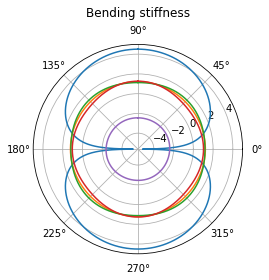

In [170]:

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})



ax.set_title("Bending stiffness", va='bottom')
plt.tight_layout()
# plt.savefig(filename, dpi = 300)
# if (not show_figure):
#     plt.close()

for data in stiffness_data_collection:
    bending_stiffness, stretching_stiffness, alphas, stiffness_coefficients = data
    sampled_stiffness = np.log(bending_stiffness)
    r = list(sampled_stiffness) + list(sampled_stiffness)
    theta = np.array(list(alphas) + list(np.pi + np.array(alphas))) + np.pi / 2


    ax.plot(theta, r)
ax.grid(True)

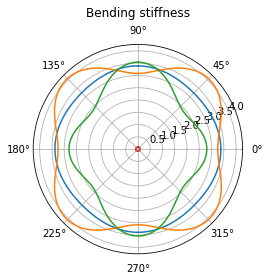

In [171]:

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})



ax.set_title("Bending stiffness", va='bottom')
plt.tight_layout()
# plt.savefig(filename, dpi = 300)
# if (not show_figure):
#     plt.close()

for data in stiffness_data_collection[1:]:
    bending_stiffness, stretching_stiffness, alphas, stiffness_coefficients = data
    sampled_stiffness = (bending_stiffness)
    r = list(sampled_stiffness) + list(sampled_stiffness)
    theta = np.array(list(alphas) + list(np.pi + np.array(alphas))) + np.pi / 2


    ax.plot(theta, r)
ax.grid(True)

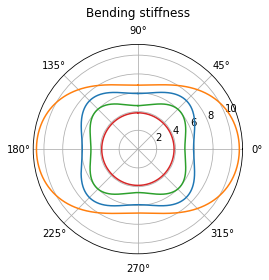

In [172]:

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})



ax.set_title("Bending stiffness", va='bottom')
plt.tight_layout()
# plt.savefig(filename, dpi = 300)
# if (not show_figure):
#     plt.close()

for data in stiffness_data_collection[1:]:
    bending_stiffness, stretching_stiffness, alphas, stiffness_coefficients = data
    sampled_stiffness = (stretching_stiffness)
    r = list(sampled_stiffness) + list(sampled_stiffness)
    theta = np.array(list(alphas) + list(np.pi + np.array(alphas))) + np.pi / 2


    ax.plot(theta, r)
ax.grid(True)

In [173]:
# plot parallel tube and isotropy separate

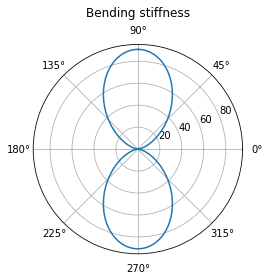

In [174]:

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})


ax.set_title("Bending stiffness", va='bottom')
plt.tight_layout()

for data in stiffness_data_collection[:1]:
    bending_stiffness, stretching_stiffness, alphas, stiffness_coefficients = data
    sampled_stiffness = (bending_stiffness)
    r = list(sampled_stiffness) + list(sampled_stiffness)
    theta = np.array(list(alphas) + list(np.pi + np.array(alphas))) + np.pi / 2


    ax.plot(theta, r)
ax.grid(True)
fig.savefig("parallel_tube_bending_stiffness.svg", dpi = 300)

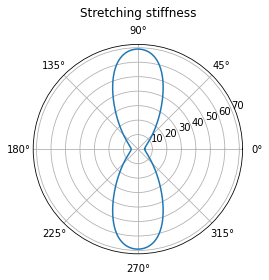

In [175]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})


ax.set_title("Stretching stiffness", va='bottom')
plt.tight_layout()
for data in stiffness_data_collection[:1]:
    bending_stiffness, stretching_stiffness, alphas, stiffness_coefficients = data
    sampled_stiffness = (stretching_stiffness)
    r = list(sampled_stiffness) + list(sampled_stiffness)
    theta = np.array(list(alphas) + list(np.pi + np.array(alphas)))


    ax.plot(theta, r)
ax.grid(True)
fig.savefig("parallel_tube_stretching_stiffness.svg", dpi = 300)

In [181]:
np.max(bending_stiffness_collection)


4.0651295952876785

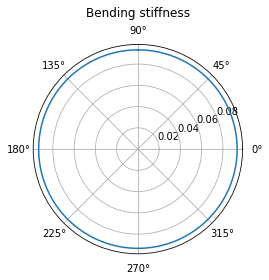

In [183]:

fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})


ax.set_title("Bending stiffness", va='bottom')
plt.tight_layout()

for data in stiffness_data_collection[-1:]:
    bending_stiffness, stretching_stiffness, alphas, stiffness_coefficients = data
    bending_stiffness = np.ones(len(bending_stiffness)) * np.max(bending_stiffness)
    sampled_stiffness = (bending_stiffness)
    r = list(sampled_stiffness) + list(sampled_stiffness)
    theta = np.array(list(alphas) + list(np.pi + np.array(alphas))) + np.pi / 2

    ax.set_rmax(np.max(bending_stiffness_collection))
    ax.set_rmin(0)

    ax.plot(theta, r)
ax.grid(True)
fig.savefig("three_star_bending_stiffness.svg", dpi = 300)

In [176]:
# fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})


# ax.set_title("Stretching stiffness", va='bottom')
# plt.tight_layout()
# for data in stiffness_data_collection[-1:]:
#     bending_stiffness, stretching_stiffness, alphas, stiffness_coefficients = data
#     sampled_stiffness = (stretching_stiffness)
#     r = list(sampled_stiffness) + list(sampled_stiffness)
#     theta = np.array(list(alphas) + list(np.pi + np.array(alphas)))


#     ax.plot(theta, r)
# ax.grid(True)
# fig.savefig("three_star_stretching_stiffness.svg", dpi = 300)

In [177]:
labels = ['parallel_tube', 'dash_line', 'cosine', 'elliptic_holes', 'three_star']

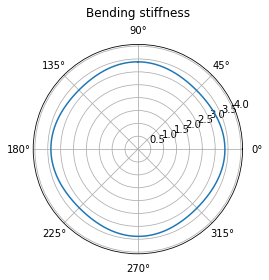

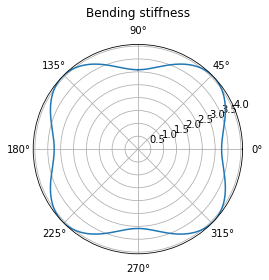

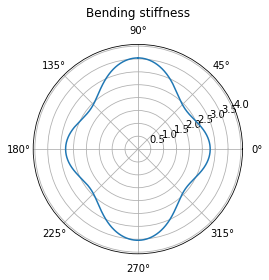

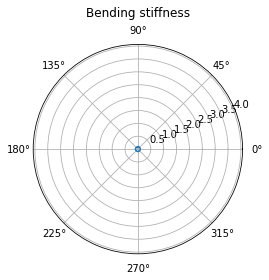

In [185]:
# Then plot the three families

# First get the max values of the bending stiffness and stretching stiffness
bending_stiffness_collection = [data[0] for data in stiffness_data_collection[1:-1]]
stretching_stiffness_collection = [data[1] for data in stiffness_data_collection[1:-1]]


for i in [1, 2, 3, 4]:

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.set_title("Bending stiffness", va='bottom')
    plt.tight_layout()
    
    data = stiffness_data_collection[i]
    label = labels[i]

    bending_stiffness, stretching_stiffness, alphas, stiffness_coefficients = data
    if i == 4:
        bending_stiffness = np.ones(len(bending_stiffness)) * np.max(bending_stiffness)

    sampled_stiffness = (bending_stiffness)
    r = list(sampled_stiffness) + list(sampled_stiffness)
    theta = np.array(list(alphas) + list(np.pi + np.array(alphas))) + np.pi / 2


    ax.plot(theta, r, )
    
    ax.set_rmax(np.max(bending_stiffness_collection))
    ax.set_rmin(0)
    ax.grid(True)
    fig.savefig("{}_bending_stiffness.svg".format(label), dpi = 300)

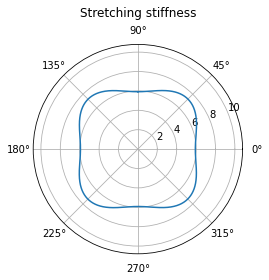

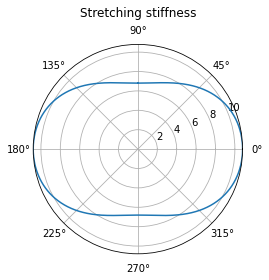

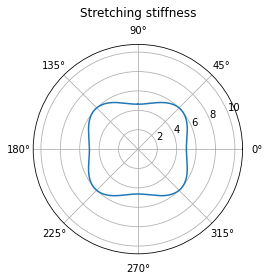

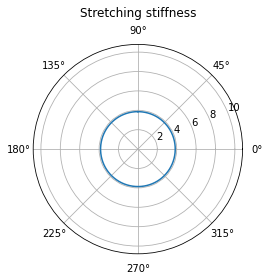

In [186]:
for i in [1, 2, 3, 4]:

    fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
    ax.set_title("Stretching stiffness", va='bottom')
    plt.tight_layout()
    
    data = stiffness_data_collection[i]
    label = labels[i]

    bending_stiffness, stretching_stiffness, alphas, stiffness_coefficients = data
    sampled_stiffness = (stretching_stiffness)
    r = list(sampled_stiffness) + list(sampled_stiffness)
    theta = np.array(list(alphas) + list(np.pi + np.array(alphas))) + np.pi / 2


    ax.plot(theta, r, )
    
    ax.set_rmax(np.max(stretching_stiffness_collection))
    ax.set_rmin(0)
    ax.grid(True)
    fig.savefig("{}_stretching_stiffness.svg".format(label), dpi = 300)